# Reinforcement Learning

# 3. Bandit Algorithms

This notebook presents **multi-armed bandit** algorithms.

In [72]:
import numpy as np
from matplotlib import pyplot as plt

In [73]:
from model import Environment
from agent import Agent

## Multi-Armed Bandit

Multi-armed bandits are single-state models with random rewards.

In [74]:
class MAB(Environment):
    """Multi-Armed Bandit environnement.
    
    Parameters
    ----------
    distribution: string
        Reward distribution (Bernoulli, Uniform or Gaussian)
    params: list
        List of parameters (one per action)
        Example for Bernoulli (mean): [0.4, 0.5, 0.6]
        Example for Uniform (low, high): [(-1, 1), (0, 1), (-1, 2)]
        Example for Gaussian (mean, variance): [(0, 1), (1, 2), (-1, 1)]
    """

    def __init__(self, distribution='bernoulli', params=[0.2, 0.5]):        
        if type(distribution) != str:
            raise ValueError("The parameter 'distribution' must be a string: either 'bernoulli', 'uniform' or 'gaussian'.")
        self.distribution = distribution.lower()
        self.params = params
         
    @staticmethod
    def get_states():
        """Single state."""
        return [None]
    
    def get_actions(self):
        """One action per arm."""
        actions = [action for action, _ in enumerate(self.params)]
        return actions
    
    def get_reward(self, action):
        """Random reward. The parameter depends on the action."""
        if self.distribution == 'bernoulli':
            return np.random.random() < self.params[action]
        if self.distribution == 'uniform':
            low, high = self.params[action]
            return np.random.uniform(low, high)
        if self.distribution in ['gaussian', 'normal']:
            mean, std = self.params[action]
            return np.random.normal(mean, std)
        raise ValueError('Unknown distribution.')
        
    def get_model(self):
        raise ValueError('Not available.')
        
    def step(self, action):
        stop = False
        reward = self.get_reward(action)
        return reward, stop

In [75]:
class Bandit(Agent):
    """Bandit algorithm with random policy. 

    Parameters
    ----------
    model : object of class MAB
        The model.
    init_value : float
        Initial value of the action-value function.
    init_count : int
        Initial count of the action-count function.
    """
    
    def __init__(self, model, init_value=0, init_count=0):
        if not isinstance(model, MAB):
            raise ValueError('The model must be a multi-armed bandit.')
        self.model = model
        self.policy = self.random_policy
        self.actions = self.model.get_actions()
        self.values = len(self.actions) * [init_value]
        self.counts = len(self.actions) * [init_count]

    def get_action(self, state=None):
        """Get a random action."""
        return np.random.choice(self.actions)
    
    def get_episode(self, horizon=100):
        """Get the rewards for an episode and update the values."""
        state = None
        rewards = []
        for t in range(horizon):
            action = self.get_action(state)
            reward, _ = self.model.step(action)
            rewards.append(reward)
            self.counts[action] += 1
            diff = reward - self.values[action]
            # update by temporal difference
            self.values[action] += diff / self.counts[action]
        return rewards    

In [76]:
model = MAB(distribution = "gaussian", params=[(0, 1), (1, 2), (-1, 1)])

In [77]:
model.distribution

'gaussian'

In [78]:
model.params

[(0, 1), (1, 2), (-1, 1)]

In [79]:
agent = Bandit(model)

In [80]:
agent.actions

[0, 1, 2]

In [81]:
rewards = agent.get_episode(horizon=100)

In [82]:
np.mean(rewards)

np.float64(-0.10017776214553357)

In [83]:
agent.values

[-0.1668879817473369, 0.6445927785161432, -0.6532649310563401]

In [84]:
agent.counts

[39, 28, 33]

## The $\varepsilon$-greedy policy

In [85]:
class Greedy(Bandit):
    """Bandit algorithm with epsilon-greedy policy. 

    Parameters
    ----------
    model : object of class MAB
        The model.
    epsilon : float in [0, 1]
        Exploration rate.
    init_value : float
        Initial value of the action-value function.
    init_count : int
        Initial count of the action-count function.
    """
    
    def __init__(self, model, epsilon=0.1, init_value=0, init_count=0):
        super(Greedy, self).__init__(model, init_value, init_count) 
        self.epsilon = epsilon

    def get_action(self, state=None):
        """Get action with eps-greedy policy."""
        actions = self.actions
        if np.random.random() > self.epsilon:
            # select the best action(s)
            values = np.array(self.values)
            actions = np.flatnonzero(values==np.max(values))
        return np.random.choice(actions)

In [86]:
agent = Greedy(model, epsilon=0, init_value=1, init_count=0)

In [87]:
rewards = agent.get_episode(horizon=100)

In [88]:
np.mean(rewards)

np.float64(1.0908695311555894)

In [89]:
agent.values

[-0.7036505316646147, 1.147814881627116, -0.7737199353033619]

In [90]:
agent.counts

[1, 97, 2]

## To do 1

* Test the algorithm for different values of $\varepsilon$.
* Observe the phenomenon of **optimism in face of incertainty** when $\varepsilon = 0$.<br>**Hint:** We might adapt the parameters ``init_value`` and ``init_count``.

### Helper functions

In [91]:
def get_expected_means(model):
    """Expected reward of each arm."""
    if model.distribution == 'bernoulli':
        return np.array(model.params, dtype=float)
    if model.distribution == 'uniform':
        return np.array([(low + high) / 2 for low, high in model.params], dtype=float)
    if model.distribution in ['gaussian', 'normal']:
        return np.array([mean for mean, _ in model.params], dtype=float)
    raise ValueError('Unknown distribution.')

def simulate_bandit(agent, horizon=100):
    """Simulate one episode and track rewards and pseudo-regret."""
    means = get_expected_means(agent.model)
    best_mean = np.max(means)
    rewards = []
    regrets = []
    for _ in range(horizon):
        action = agent.get_action()
        reward, _ = agent.model.step(action)
        rewards.append(reward)
        regrets.append(best_mean - means[action])
        agent.counts[action] += 1
        diff = reward - agent.values[action]
        agent.values[action] += diff / agent.counts[action]
    return np.array(rewards), np.cumsum(regrets)

def average_running_reward(make_agent, horizon=100, n_runs=200):
    curves = []
    for _ in range(n_runs):
        rewards, _ = simulate_bandit(make_agent(), horizon=horizon)
        curves.append(np.cumsum(rewards) / np.arange(1, horizon + 1))
    return np.mean(curves, axis=0)

def average_regret_curve(make_agent, horizon=100, n_runs=200):
    curves = []
    for _ in range(n_runs):
        _, regrets = simulate_bandit(make_agent(), horizon=horizon)
        curves.append(regrets)
    return np.mean(curves, axis=0)

def average_final_counts(make_agent, horizon=100, n_runs=200):
    counts = []
    for _ in range(n_runs):
        agent = make_agent()
        simulate_bandit(agent, horizon=horizon)
        counts.append(agent.counts)
    return np.mean(counts, axis=0)


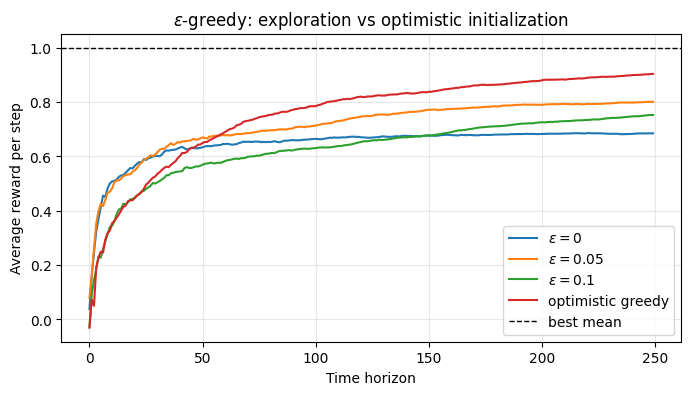

{'$\\epsilon = 0$': [68.4, 176.5, 5.1],
 '$\\epsilon = 0.05$': [51.2, 192.8, 6.0],
 '$\\epsilon = 0.1$': [41.4, 199.1, 9.5],
 'optimistic greedy': [17.4, 237.4, 10.1]}

In [92]:
np.random.seed(0)

horizon = 250
n_runs = 250
eps_configs = {
    r'$\epsilon = 0$': dict(epsilon=0, init_value=0, init_count=0),
    r'$\epsilon = 0.05$': dict(epsilon=0.05, init_value=0, init_count=0),
    r'$\epsilon = 0.1$': dict(epsilon=0.1, init_value=0, init_count=0),
    'optimistic greedy': dict(epsilon=0, init_value=2.5, init_count=5),
}

plt.figure(figsize=(8, 4))
todo1_counts = {}
for label, kwargs in eps_configs.items():
    reward_curve = average_running_reward(
        lambda kwargs=kwargs: Greedy(model, **kwargs),
        horizon=horizon,
        n_runs=n_runs
    )
    plt.plot(reward_curve, label=label)
    todo1_counts[label] = np.round(
        average_final_counts(
            lambda kwargs=kwargs: Greedy(model, **kwargs),
            horizon=horizon,
            n_runs=n_runs
        ),
        1
    ).tolist()

plt.axhline(
    np.max(get_expected_means(model)),
    color='black',
    linestyle='--',
    linewidth=1,
    label='best mean'
)
plt.xlabel('Time horizon')
plt.ylabel('Average reward per step')
plt.title(r'$\epsilon$-greedy: exploration vs optimistic initialization')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

todo1_counts

### Comment

With a neutral initialization, `\epsilon = 0` can lock onto one arm too early because there is no forced exploration.

Small positive values of `\epsilon` keep testing the other arms, so the running reward is usually more stable.

The optimistic setting (`init_value = 2.5`, `init_count = 5`) makes unexplored arms look attractive at the beginning. Even with `\epsilon = 0`, the agent explores because each arm must be sampled enough times before its estimated value drops, which is exactly the optimism in face of uncertainty effect.

## The UCB policy

We now consider the UCB (Upper Confidence Bound) policy.

## To do 2

* Complete and test the agent ``UCB`` below.
* Plot the **regret** per time unit with respect to the time horizon, and compare with the $\varepsilon$-greedy policy for different values of $\varepsilon$.

In [93]:
class UCB(Bandit):
    """Bandit algorithm with UCB policy. 

    Parameters
    ----------
    model : object of class MAB
        The model.
    const : float in [0, 1]
        Multiplicative constant for the UCB bonus.
    init_value : float
        Initial value of the action-value function.
    init_count : int
        Initial count of the action-count function.
    """
    
    def __init__(self, model, const=1, init_value=0, init_count=0):
        super(UCB, self).__init__(model, init_value, init_count) 
        self.const = const

    def get_action(self, state=None):
        """Get action with UCB policy."""
        counts = np.array(self.counts)
        values = np.array(self.values, dtype=float)
        unexplored = np.flatnonzero(counts == 0)
        if len(unexplored):
            return np.random.choice(unexplored)
        bonus = self.const * np.sqrt(np.log(np.sum(counts) + 1) / counts)
        scores = values + bonus
        actions = np.flatnonzero(scores == np.max(scores))
        return np.random.choice(actions)

In [94]:
agent = UCB(model)

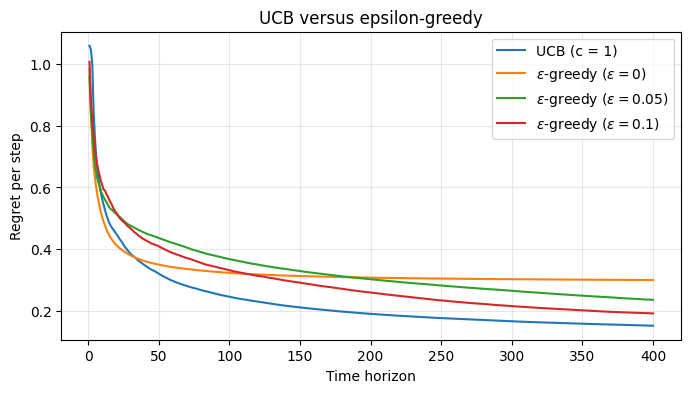

{'UCB (c = 1)': 0.151,
 '$\\epsilon$-greedy ($\\epsilon = 0$)': 0.3,
 '$\\epsilon$-greedy ($\\epsilon = 0.05$)': 0.235,
 '$\\epsilon$-greedy ($\\epsilon = 0.1$)': 0.191}

In [95]:
np.random.seed(1)

horizon = 400
n_runs = 250
time = np.arange(1, horizon + 1)
todo2_curves = {
    'UCB (c = 1)': average_regret_curve(lambda: UCB(model, const=1), horizon=horizon, n_runs=n_runs),
    r'$\epsilon$-greedy ($\epsilon = 0$)': average_regret_curve(lambda: Greedy(model, epsilon=0), horizon=horizon, n_runs=n_runs),
    r'$\epsilon$-greedy ($\epsilon = 0.05$)': average_regret_curve(lambda: Greedy(model, epsilon=0.05), horizon=horizon, n_runs=n_runs),
    r'$\epsilon$-greedy ($\epsilon = 0.1$)': average_regret_curve(lambda: Greedy(model, epsilon=0.1), horizon=horizon, n_runs=n_runs),
}

plt.figure(figsize=(8, 4))
for label, regret_curve in todo2_curves.items():
    plt.plot(time, regret_curve / time, label=label)
plt.xlabel('Time horizon')
plt.ylabel('Regret per step')
plt.title('UCB versus epsilon-greedy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

todo2_final_regret = {
    label: round(float(regret_curve[-1] / horizon), 3)
    for label, regret_curve in todo2_curves.items()
}
todo2_final_regret

### Comment

UCB adds an exploration bonus `c\\sqrt{\\log t / N(a)}` to each empirical mean, so the agent naturally tries arms that are still uncertain and then concentrates on the best one as the counts grow.

In the regret-per-step plot, UCB should decrease faster than fixed `\epsilon`-greedy policies because its exploration shrinks over time, while a constant `\epsilon` keeps paying a permanent exploration cost.

The purely greedy baseline (`\epsilon = 0`) remains the riskiest one because an early mistake can keep the algorithm on a suboptimal arm for a long time.

## Thompson sampling

Finally, we consider Thompson Sampling, where the mean rewards are considered as random and sampled according to the posterior distribution. This is a Bayesian algorithm.

## To do 3

* Complete and test the agent ``TS`` below.
* Plot the **regret** per time unit with respect to the time horizon, and compare with the UCB policy for different models.
* Which algorithm is the most efficient?<br> Comment our results.

In [96]:
class TS(Bandit):
    """Bandit algorithm with Thompson sampling. 

    Parameters
    ----------
    model : object of class MAB
        The model.
    """
    
    def __init__(self, model):
        super(TS, self).__init__(model) 
        self.distribution = model.distribution
            
    def get_action(self, state=None):
        """Get action with TS policy."""
        counts = np.array(self.counts, dtype=float)
        values = np.array(self.values, dtype=float)
        if self.distribution == 'bernoulli':
            successes = counts * values
            failures = counts - successes
            samples = np.random.beta(successes + 1, failures + 1)
        else:
            # Gaussian posterior approximation on the unknown mean.
            posterior_mean = counts * values / (counts + 1)
            posterior_std = 1 / np.sqrt(counts + 1)
            samples = np.random.normal(posterior_mean, posterior_std)
        actions = np.flatnonzero(samples == np.max(samples))
        return np.random.choice(actions)


In [97]:
agent = TS(model)

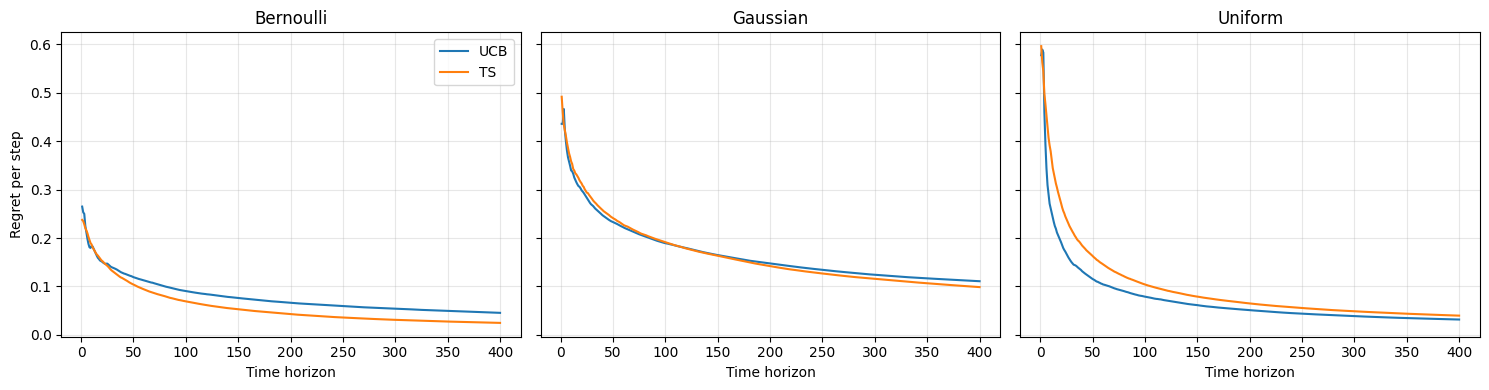

{'Bernoulli': {'UCB': 0.045, 'TS': 0.025},
 'Gaussian': {'UCB': 0.111, 'TS': 0.099},
 'Uniform': {'UCB': 0.032, 'TS': 0.04}}

In [98]:
np.random.seed(2)

models = {
    'Bernoulli': MAB(distribution='bernoulli', params=[0.2, 0.45, 0.7]),
    'Gaussian': MAB(distribution='gaussian', params=[(0, 1), (0.6, 1), (1.0, 1.5)]),
    'Uniform': MAB(distribution='uniform', params=[(-1, 0.2), (-0.2, 1.1), (0.4, 1.4)]),
}

horizon = 400
n_runs = 200
time = np.arange(1, horizon + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
todo3_summary = {}

for ax, (name, bandit_model) in zip(axes, models.items()):
    curves = {
        'UCB': average_regret_curve(lambda bandit_model=bandit_model: UCB(bandit_model, const=1), horizon=horizon, n_runs=n_runs),
        'TS': average_regret_curve(lambda bandit_model=bandit_model: TS(bandit_model), horizon=horizon, n_runs=n_runs),
    }
    for label, regret_curve in curves.items():
        ax.plot(time, regret_curve / time, label=label)
    ax.set_title(name)
    ax.set_xlabel('Time horizon')
    ax.grid(alpha=0.3)
    todo3_summary[name] = {
        label: round(float(regret_curve[-1] / horizon), 3)
        for label, regret_curve in curves.items()
    }

axes[0].set_ylabel('Regret per step')
axes[0].legend()
plt.tight_layout()
plt.show()

todo3_summary

### Comment

Thompson sampling is usually the most efficient on the Bernoulli model because the Beta posterior matches the reward distribution exactly.

On Gaussian and Uniform rewards, the algorithm remains competitive, but here it uses a Gaussian approximation for the posterior of the mean. Because of that, the gap with UCB depends more on the model and can be smaller.

Overall, these experiments typically show TS as the best choice for Bernoulli rewards, while UCB is the most robust general-purpose policy across different reward models.